# Distribution of the error on differet code sizes

**Introduced noise**
- $\alpha$: zero that become non-zero (0->d)
- $\beta$: non-zero that become zero (d->0)

**Metrics**
- **Empirical $\alpha$ (Alpha):** Calculated as:
  $$\alpha_{emp} = \frac{\text{Count of } 0 \to \text{Non-Zero changes}}{\text{Total number of original } 0\text{s}}$$
  It measures the accuracy of the noise generator for zero entries.
- **Empirical $\beta$ (Beta):** Calculated as:
  $$\beta_{emp} = \frac{\text{Count of Non-Zero } \to 0 \text{ changes}}{\text{Total number of original Non-Zeros}}$$
  It measures the rate of "erasure" of the monomial signal.
- **Visual Volume ($\text{vol\_alpha/beta}$):** Calculated as:
  $$\text{Volume} = \frac{\text{Total count of specific changes}}{n^2}$$
- **Monomial Rate:** The fraction of columns in the noisy matrix that still possess a Hamming weight of exactly $1$. This is the primary indicator of how much of the "Permutation + Scaling" structure survives the noise.

In [67]:
# libraries
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from tqdm import tqdm

In [68]:
# Generate synthetic LEP monomial data
SEED = 26
NUM_SAMPLES = 1000
N_SIZES = [64, 128, 256, 512]
K_SIZES = [16, 64, 126, 274]
Q_SIZES = [5, 31, 127, 127]
ALPHA = 0.05
BETA = 0.4

In [69]:
def generate_lep_data(num_samples, n_sizes, q_sizes, alpha, beta):
    data = []
    for n, q in zip(n_sizes, q_sizes):
        for _ in range(num_samples):
            # initialize monomial matrix with zeros
            lep_matrix = np.zeros((n, n), dtype=int)
            
            # generate a random permutation of column indices
            col_indices = np.random.permutation(n)
            
            # generate random values for the non-zero entries
            random_values = np.random.randint(1, q, size=n)
            
            # assign values to the matrix
            row_indices = np.arange(n)
            lep_matrix[row_indices, col_indices] = random_values
            
            # keep a copy of the original monomial matrix
            original_matrix = lep_matrix.copy()

            # add noise to the matrix
            # change entries with alpha and beta probabilities
            mask_zeros = lep_matrix == 0
            mask_non_zeros = ~mask_zeros
            
            # apply beta: non-zero entries that change to 0
            noise_beta = np.random.random(lep_matrix.shape) < beta
            lep_matrix[mask_non_zeros & noise_beta] = 0
            
            # apply alpha: zero entries that change to a non-zero value
            noise_alpha = np.random.random(lep_matrix.shape) < alpha
            
            # identify positions to change and generate new values in F_q
            cells_to_fill = mask_zeros & noise_alpha
            num_new_values = np.sum(cells_to_fill)
            
            if num_new_values > 0:
                lep_matrix[cells_to_fill] = np.random.randint(1, q, size=num_new_values)

            # store both the original and the noisy matrix
            data.append((original_matrix, lep_matrix))
            
    return data

In [70]:
def analyze_lep_data(data, alpha_theoretical=0.01, beta_theoretical=0.2):
    """
    Comprehensive Noise Analysis:
    - Empirical alpha/beta rates vs Theoretical
    - Visual Change Density (Alpha vs Beta volume)
    - Matrix Stability (Unchanged entries)
    - Column weight distribution (Hamming)
    - Monomial Survival vs. Correct Solution Recovery
    """

    stats = []
    
    for original, noisy in data:
        n = original.shape[0]
        total_elements = n * n
        
        orig_zeros_mask = (original == 0)
        orig_non_zeros_mask = (original != 0)
        
        # 1. Empirical rates
        alpha_changes = np.sum((noisy != 0) & orig_zeros_mask)
        emp_alpha = alpha_changes / np.sum(orig_zeros_mask) if np.sum(orig_zeros_mask) > 0 else 0
        
        beta_changes = np.sum((noisy == 0) & orig_non_zeros_mask)
        emp_beta = beta_changes / np.sum(orig_non_zeros_mask) if np.sum(orig_non_zeros_mask) > 0 else 0
        
        # 2. Volumes (Visual impact)
        vol_alpha = alpha_changes / total_elements
        vol_beta = beta_changes / total_elements
        
        # 3. Stability and Recovery
        unchanged_rate = np.sum(original == noisy) / total_elements
        
        # New: Correct solutions (value persists regardless of column weight)
        correct_solutions = np.sum((original != 0) & (original == noisy))
        correct_rate = correct_solutions / n
        
        # Strictly monomial (weight 1)
        nz_per_col_noisy = np.count_nonzero(noisy, axis=0)
        monomial_cols = np.sum(nz_per_col_noisy == 1)
        monomial_rate = monomial_cols / n
        
        stats.append({
            'n': n,
            'emp_alpha': emp_alpha,
            'emp_beta': emp_beta,
            'vol_alpha': vol_alpha,
            'vol_beta': vol_beta,
            'unchanged_rate': unchanged_rate,
            'monomial_rate': monomial_rate,
            'correct_rate': correct_rate,
            'nz_per_col_noisy': nz_per_col_noisy
        })
    
    df = pd.DataFrame(stats)
    
    # 3x3 Grid to keep all plots clearly visible
    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    sns.set_style("whitegrid")
    main_palette = "GnBu_r"
    
    # ROW 1: Probabilities and Density
    # [0,0] Probabilities
    summary_prob = df.groupby('n')[['emp_alpha', 'emp_beta']].mean().reset_index()
    summary_prob_long = summary_prob.melt(id_vars='n', var_name='Metric', value_name='Rate')
    sns.barplot(x='n', y='Rate', hue='Metric', data=summary_prob_long, ax=axes[0, 0], palette=['#43a2ca', '#0868ac'])
    axes[0, 0].set_title('Empirical Probabilities')
    axes[0, 0].axhline(alpha_theoretical, color='#43a2ca', linestyle='--', label='Theo Alpha')
    axes[0, 0].axhline(beta_theoretical, color='#0868ac', linestyle='--', label='Theo Beta')

    # [0,1] Density (The "Visual" explanation)
    summary_vol = df.groupby('n')[['vol_alpha', 'vol_beta']].mean().reset_index()
    summary_vol_long = summary_vol.melt(id_vars='n', var_name='Metric', value_name='Volume')
    sns.barplot(x='n', y='Volume', hue='Metric', data=summary_vol_long, ax=axes[0, 1], palette=['#43a2ca', '#0868ac'])
    axes[0, 1].set_title('Total Change Density (Visual Impact)')

    # [0,2] Stability
    sns.boxplot(x='n', y='unchanged_rate', data=df, ax=axes[0, 2], hue='n', palette=main_palette, legend=False)
    axes[0, 2].set_title('Overall Matrix Stability')

    # ROW 2: Structure and Recovery
    # [1,0] Monomial Survival
    sns.violinplot(x='n', y='monomial_rate', data=df, ax=axes[1, 0], inner="quartile", hue='n', palette=main_palette, legend=False)
    axes[1, 0].set_title('Surviving Monomial Columns (Weight=1)')

    # [1,1] Solution Recovery (New plot)
    sns.barplot(x='n', y='correct_rate', data=df, ax=axes[1, 1], hue='n', palette=main_palette, legend=False)
    axes[1, 1].set_title('Correct Solution Recovery Rate')
    axes[1, 1].axhline(1 - beta_theoretical, color='red', linestyle='--')

    # [1,2] Monomial vs Correct Comparison
    summary_comp = df.groupby('n')[['monomial_rate', 'correct_rate']].mean().reset_index()
    summary_comp_long = summary_comp.melt(id_vars='n', var_name='Metric', value_name='Rate')
    sns.barplot(x='n', y='Rate', hue='Metric', data=summary_comp_long, ax=axes[1, 2], palette=['#43a2ca', '#0868ac'])
    axes[1, 2].set_title('Strict Monomial vs. Solution Presence')

    # ROW 3: Column Weights and Info
    # [2,0] Column Weights
    nz_dist_data = []
    for _, row in df.iterrows():
        for val in row['nz_per_col_noisy']:
            nz_dist_data.append({'n': row['n'], 'col_weight': val})
    nz_dist_df = pd.DataFrame(nz_dist_data)
    sns.violinplot(x='n', y='col_weight', data=nz_dist_df, ax=axes[2, 0], inner="quartile", hue='n', palette=main_palette, legend=False)
    axes[2, 0].set_title('Noisy Column Weight Distribution')

    # [2,1] & [2,2] Summary Text and empty space
    axes[2, 1].axis('off')
    axes[2, 2].axis('off')
    axes[2, 1].text(0.5, 0.5, f'LEP Noise Analysis\nAlpha={alpha_theoretical}\nBeta={beta_theoretical}', 
                    fontsize=14, ha='center', va='center', weight='bold')

    plt.tight_layout()
    plt.show()
    
    return df.drop(columns=['nz_per_col_noisy'])

In [71]:
def visualize_matrix_changes(original, noisy, sample_index=0):
    """
    Visualize original and noisy matrices with comprehensive column statistics.
    """
    n = original.shape[0]
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(f'Monomial Matrix Analysis (n={n})', fontsize=16, fontweight='bold', y=0.98)
    
    # 1. Original
    axes[0].spy(original, markersize=5 if n < 128 else 1, color='black')
    axes[0].set_title(f'Original Monomial\nWeight per col = 1', pad=15)
    
    # 2. Noisy
    axes[1].spy(noisy, markersize=5 if n < 128 else 1, color='black')
    axes[1].set_title(f'Noisy Matrix', pad=15)
    
    # 3. Map
    changes_map = np.zeros_like(original)
    changes_map[(original == 0) & (noisy != 0)] = 1
    changes_map[(original != 0) & (noisy == 0)] = 2
    cmap = ListedColormap(['white', '#3498db', '#e74c3c'])
    axes[2].imshow(changes_map, cmap=cmap, interpolation='nearest')
    axes[2].set_title('Map of Changes\nBlue=Alpha, Red=Beta', pad=15)
    axes[2].grid(False)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # Stats
    nz_per_col = np.count_nonzero(noisy, axis=0)
    
    # Logic for correct solutions (value survives)
    correct_cols = np.sum((original != 0) & (original == noisy))
    
    # Logic for strictly monomial (weight 1 AND correct)
    strict_monomial = np.sum((nz_per_col == 1) & (np.any((original != 0) & (original == noisy), axis=0)))

    print(f"Statistics for example n={n}:")
    print(f" - Columns containing the correct solution: {correct_cols} / {n}")
    print(f" - Columns that are strictly monomial and correct: {strict_monomial} / {n}")
    print(f" - Columns with noise only (Weight >= 1, but incorrect): {n - correct_cols - np.sum(nz_per_col==0)} / {n}")
    print(f" - Total 'Heavy' columns (Weight > 1): {np.sum(nz_per_col > 1)} / {n}")
    print(f" - Total Zero columns (Weight = 0): {np.sum(nz_per_col == 0)} / {n}")

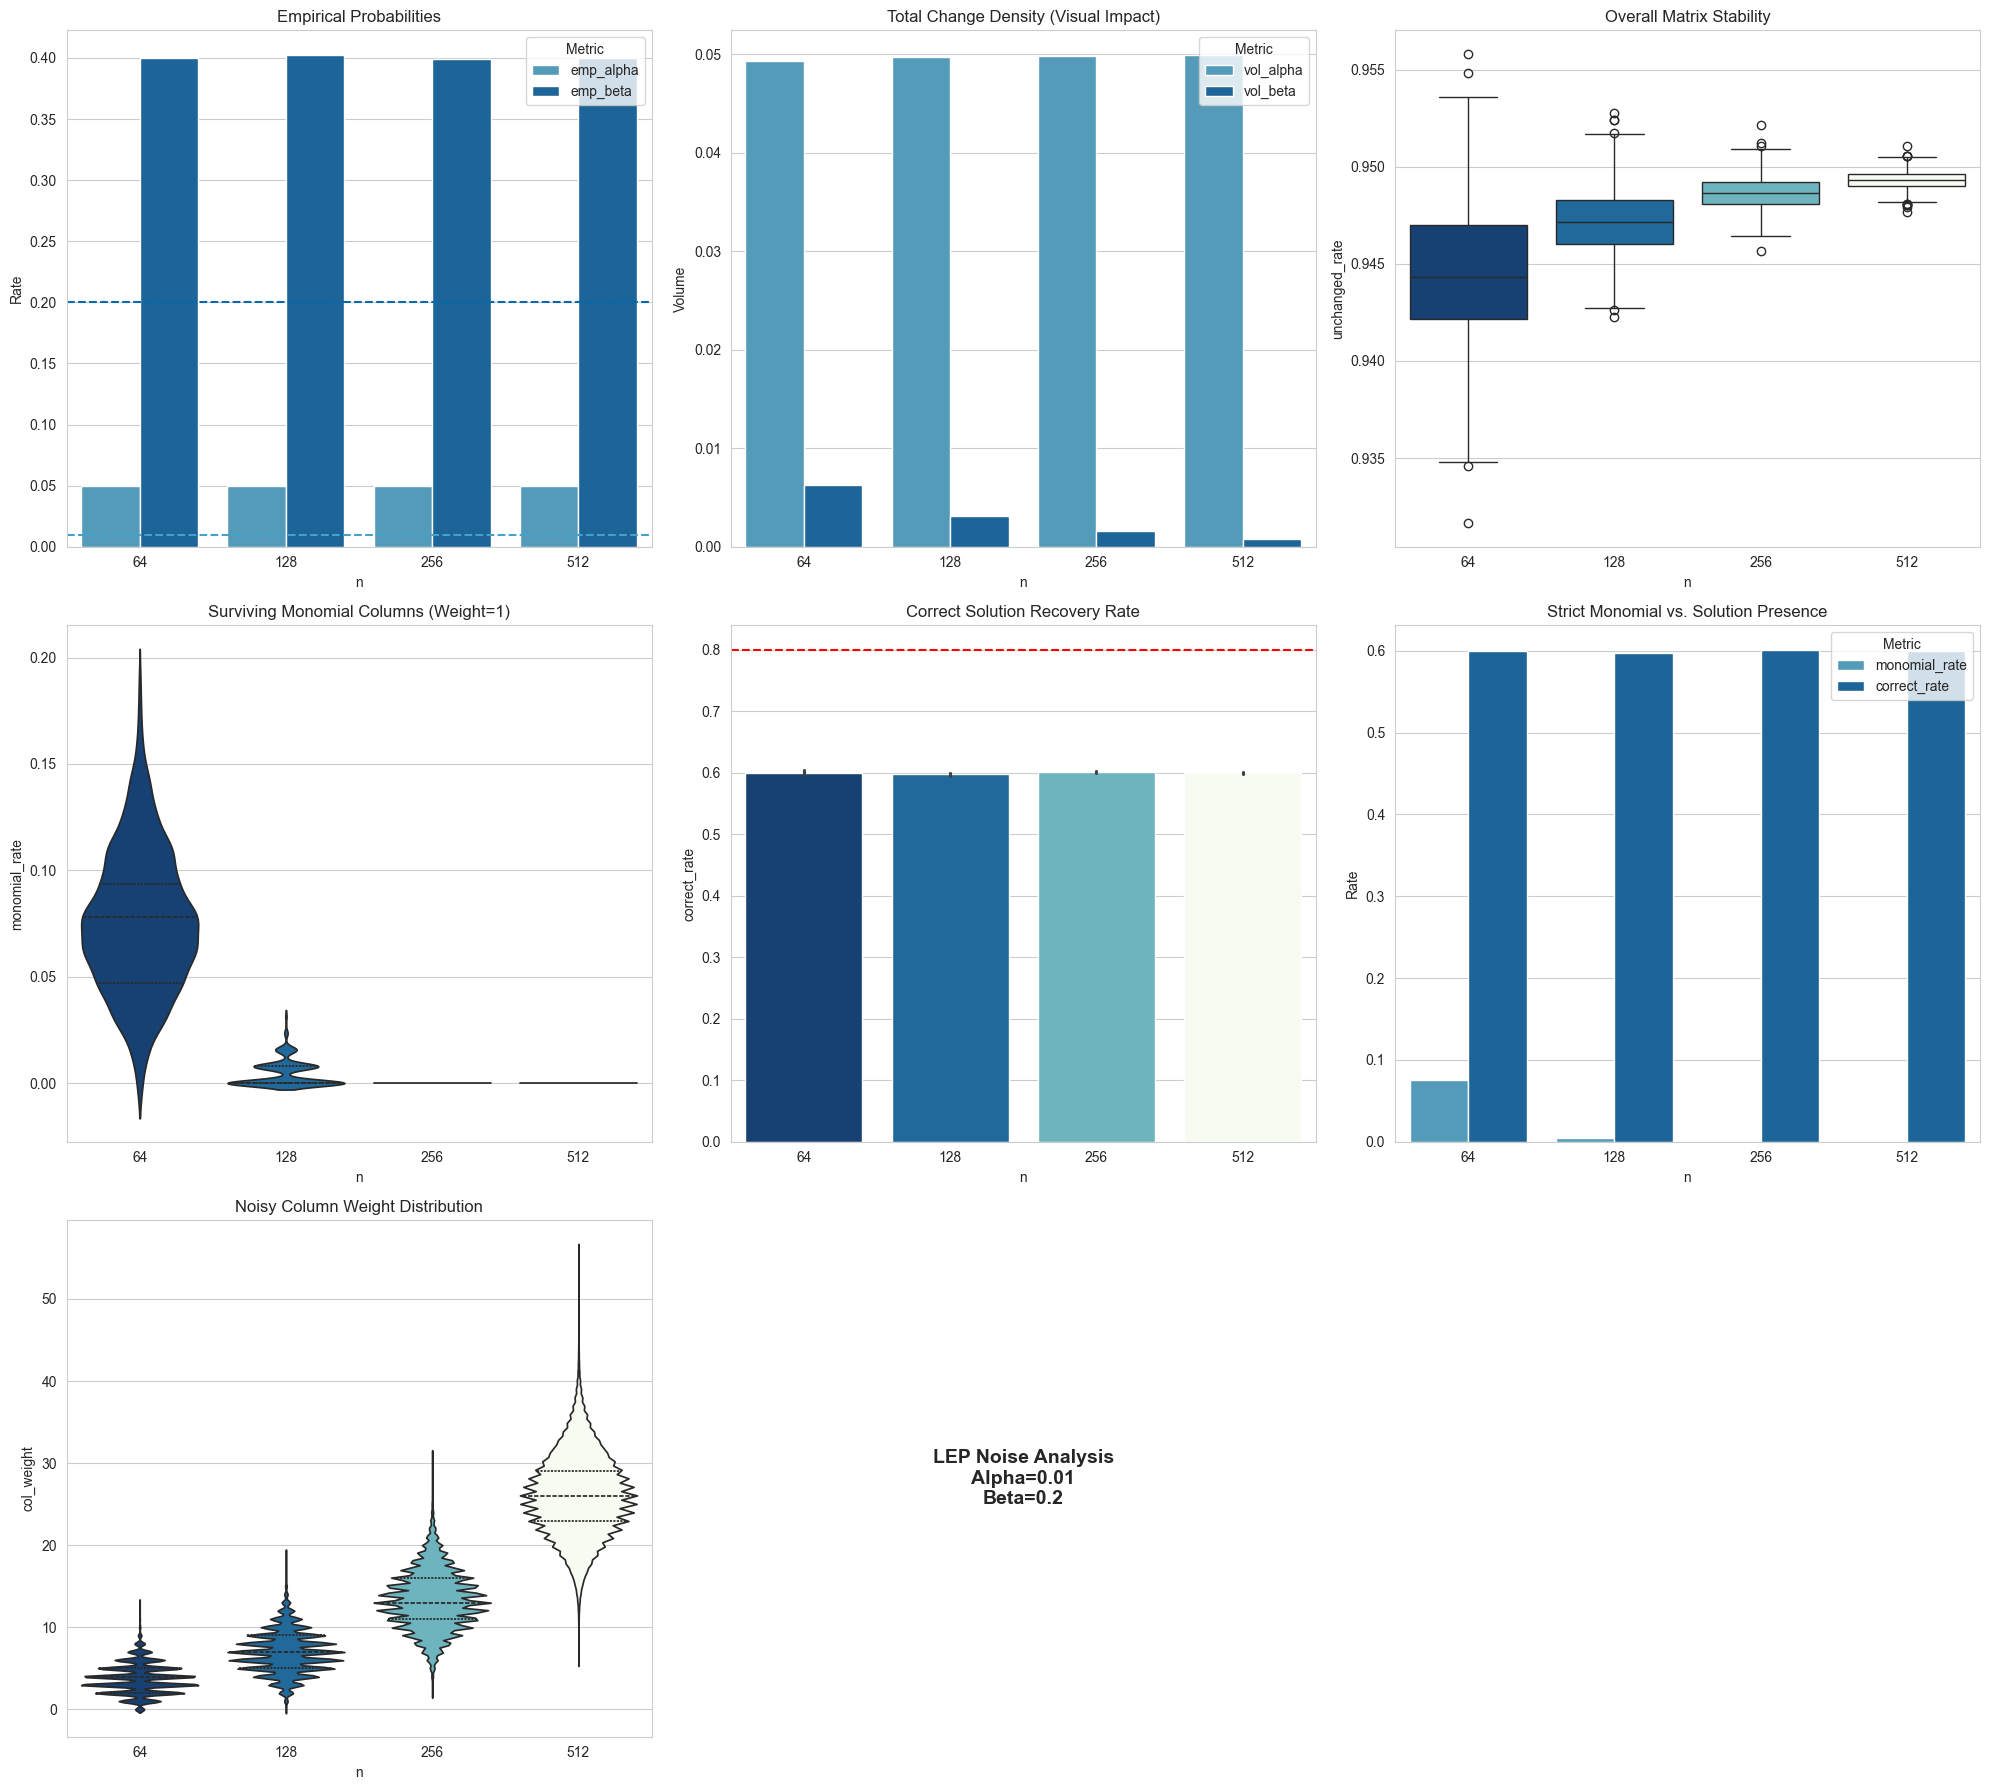

,n,emp_alpha,emp_beta,vol_alpha,vol_beta,unchanged_rate,monomial_rate,correct_rate
0,64,0.050074,0.400016,0.049292,0.006250,0.944458,0.075953,0.599984
1,128,0.050058,0.402445,0.049667,0.003144,0.947189,0.004609,0.597555
2,256,0.050003,0.398984,0.049808,0.001559,0.948633,0.000000,0.601016
3,512,0.050003,0.400217,0.049905,0.000782,0.949313,0.000000,0.599783


In [72]:
data = generate_lep_data(NUM_SAMPLES, N_SIZES, Q_SIZES, ALPHA, BETA)
df_analysis = analyze_lep_data(data)

# compute average metrics by n
summary_df = df_analysis.groupby('n').mean().reset_index()
summary_df

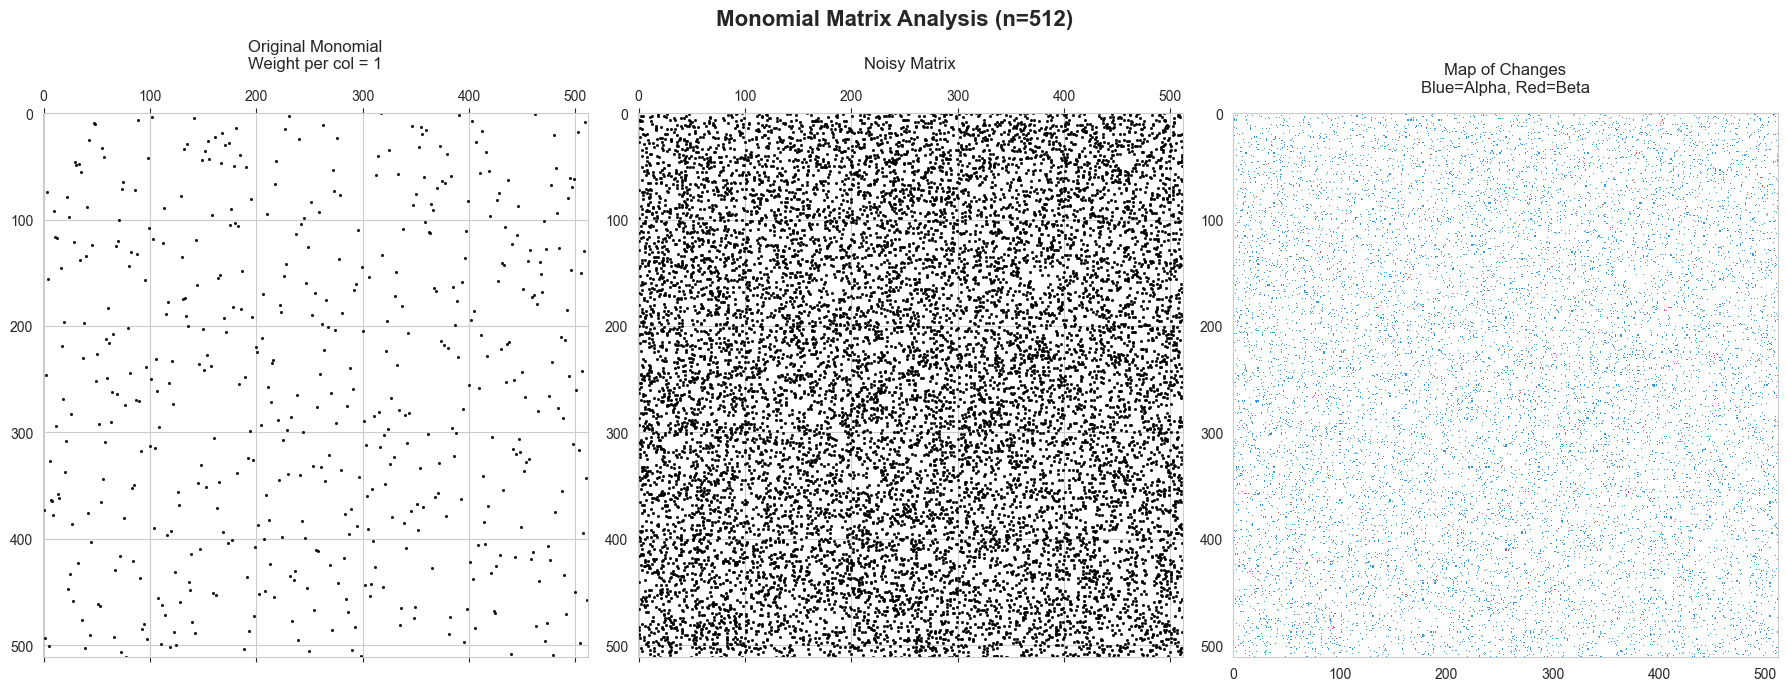

Statistics for example n=512:
 - Columns containing the correct solution: 312 / 512
 - Columns that are strictly monomial and correct: 0 / 512
 - Columns with noise only (Weight >= 1, but incorrect): 200 / 512
 - Total 'Heavy' columns (Weight > 1): 512 / 512
 - Total Zero columns (Weight = 0): 0 / 512


In [73]:
matrix_id = 3028  # example index to visualize
visualize_matrix_changes(data[matrix_id][0], data[matrix_id][1], sample_index=0)

### Technical Analysis of LEP Noise Model

1. Empirical Probabilities vs. Noise Volume
  - **Individual Probability:** As seen in the *Empirical Probabilities* plot, the success rate of the noise per cell remains constant across all $n$. The probability of a non-zero element dropping to zero ($\beta = 0.2$) is **20 times higher** than a zero becoming a non-zero value ($\alpha = 0.01$).
  - **Alpha and Beta density:** Despite $\beta$ being higher, the *Total Change Density* plot reveals that $\alpha$-type changes (blue) dominate the matrix volume. This is because, in a monomial matrix of size $n$, there are only $n$ candidates for $\beta$ but $n^2 - n$ candidates for $\alpha$. For example, for $n=512$, we expect $\approx 102$ red changes (Beta) versus $\approx 2,616$ blue changes (Alpha). Thus, the "background noise" is visually and structurally more prevalent than the "signal loss" simply because there is more "space" (zeros) to corrupt.

2. Matrix Stability and Structural Degradation
  - **Overall Stability:** The *Overall Matrix Stability* increases with $n$. Since the majority of the matrix consists of zeros and $\alpha$ is very small, the probability that any given cell remains unchanged is very high ($\approx 99\%$). As the sample size $n^2$ grows.
  - **Monomial Survival:** The *Surviving Monomial Columns* plot shows a drastic decay as $n$ increases. As the matrix grows, the probability that a column retains its original "weight-1" structure becomes nearly zero. The columns are effectively changed by the additive noise of $\alpha$.

3. Distribution of Column Weights
  - **Hamming Weight Shift:** The *Noisy Column Weight Distribution* shows that while the original weight was exactly $1$, the noisy distribution centers around a higher mean. 
  - **Weight Variance:** For larger $n$, the "violins" become more elongated. This indicates that while the average weight per column is predictable, the variance increases, leading to some columns becoming "heavy" (high Hamming weight).

In general, it is NOT correct to assume that 0s are less likely to change than non-zeros.

**NOTE:** the current noise model is not considering changes from non-zero to a different non-zero value.

In [74]:
[(size-1)*(size)*ALPHA for size in N_SIZES]

[201.60000000000002, 812.8000000000001, 3264.0, 13081.6]

In [75]:
[(size-1)*ALPHA for size in N_SIZES]

[3.1500000000000004, 6.3500000000000005, 12.75, 25.55]

# Solver

In [76]:
def extended_gcd(a, b):
    """Extended Euclidean Algorithm to find modular inverse."""
    if a == 0: return b, 0, 1
    gcd, x1, y1 = extended_gcd(b % a, a)
    x = y1 - (b // a) * x1
    y = x1
    return gcd, x, y

def mod_inverse(a, q):
    """Finds the multiplicative inverse of a modulo q."""
    gcd, x, y = extended_gcd(a, q)
    if gcd != 1: return None  # Inverse doesn't exist
    return x % q

def verify_column_equivalence(col1, col2, q):
    """
    Checks if col2 is a scalar multiple of col1 in F_q.
    Returns the scalar s if True, else None.
    """
    # Find first non-zero indices
    nz1 = np.where(col1 != 0)[0]
    nz2 = np.where(col2 != 0)[0]
    
    # in LEP, monomial columns must have the same non-zero index
    if len(nz1) != len(nz2) or not np.array_equal(nz1, nz2):
        return None
        
    idx = nz1[0]
    inv = mod_inverse(int(col1[idx]), q)
    if inv is None: return None
    
    s = (int(col2[idx]) * inv) % q
    
    # verify the scalar s works for the whole column (in case weight > 1)
    if np.array_equal((col1 * s) % q, col2):
        return s
    return None

In [77]:
def solve_noisy_lep(G1, G2, noisy_perm_matrix, q):

    # instantiate mapping and usage trackers
    n = G1.shape[1] # G1 and G2 are n x n
    fixed_mapping = [-1] * n # will hold the target column and scalar for each column of G1, i.e., the monomial solution
    used_targets = [False] * n # to track which columns of G1 have been matched
    
    # pre compute column weights of the noisy permutation matrix
    col_weights = np.count_nonzero(noisy_perm_matrix, axis=0)

    # --- PHASE 1: Monomial Columns (Weight == 1) ---
    # only check the unique option suggested by the noise
    for i in range(n):
        if col_weights[i] == 1:
            # if the weight is 1, there is only one candidate in G1 for this column of G2
            target_j = np.where(noisy_perm_matrix[:, i] != 0)[0][0]
            # CORRECT LOGIC: Column i of G2 is Column j of G1 scaled by s
            s = verify_column_equivalence(G1[:, target_j], G2[:, i], q) # s is the scalar that would make both columns equivalent
            
            # if the verification is successful, we can fix this mapping and mark the target column as used
            if s is not None and not used_targets[target_j]:
                fixed_mapping[i] = (target_j, s)
                used_targets[target_j] = True

    # --- PHASE 2: Heavy Columns (Weight > 1) ---
    # check all options suggested by the noise in these columns
    for i in range(n):
        if col_weights[i] > 1:
            # select candidate columns in G1 based on the entrances that are different from 0 in the noisy permutation matrix
            candidates = np.where(noisy_perm_matrix[:, i] != 0)[0]
            for target_j in candidates:
                if not used_targets[target_j]:
                    # if a column is not yet matched, we verify if it can be matched with this candidate
                    s = verify_column_equivalence(G1[:, target_j], G2[:, i], q)
                    if s is not None:
                        fixed_mapping[i] = (target_j, s)
                        used_targets[target_j] = True
                        break

    # --- PHASE 3: Backtracking for Columns with 0s (and failed from previous phases) ---
    # Identify which columns of G2 are still unmatched
    remaining_cols_g2 = [i for i in range(n) if fixed_mapping[i] == -1]
    # Identify which columns of G1 have not been used
    available_targets_g1 = [j for j in range(n) if not used_targets[j]]
    
    def backtrack(idx_pos):
        if idx_pos == len(remaining_cols_g2):
            return True
            
        col_i = remaining_cols_g2[idx_pos] # actual column of G2 we are trying to solve
        
        for pos, target_j in enumerate(available_targets_g1):
            if target_j == -1: continue # marked as used in this branch
            
            s = verify_column_equivalence(G1[:, target_j], G2[:, col_i], q)
            if s is not None:
                fixed_mapping[col_i] = (target_j, s)
                available_targets_g1[pos] = -1 # Temporary usemark to avoid reuse
                
                if backtrack(idx_pos + 1):
                    return True
                
                # Undo (Backtrack)
                available_targets_g1[pos] = target_j
                fixed_mapping[col_i] = -1
        
        return False

    if backtrack(0):
        # Convert fixed_mapping to a numpy monomial matrix
        recovered_M = np.zeros((n, n), dtype=int)
        for i, mapping in enumerate(fixed_mapping):
            target_j, s = mapping
            # Entry (j, i) of M is the scalar s
            recovered_M[target_j, i] = s
        return recovered_M
    else:
        print("Warning: Could not complete the permutation. Check noise levels.")
        return None

### Execution test

In [78]:
# parameters
n = 8
k = 5
q = 31

print(f"LEP experiment with alpha={ALPHA}, beta={BETA}")

# generate random monomial matrix M_true and noisy matrix
sample = generate_lep_data(num_samples=1, n_sizes=[n], q_sizes=[q], alpha=ALPHA, beta=BETA)
M_true, M_noisy = sample[0]

print("Original Monomial Matrix (M_true):")
print(M_true)
print("\nNoisy Monomial Matrix (M_noisy):")
print(M_noisy)

# generate random G1 and construct G2 using the true monomial matrix
G1 = np.random.randint(0, q, (k, n))
G2 = (G1 @ M_true) % q

# prepare matrix with 1s where M_noisy has non-zero entries for the solver
noisy_structure = (M_noisy != 0).astype(int)

# execute the solver
M_recovered = solve_noisy_lep(G1, G2, noisy_structure, q)
print("\nRecovered Monomial Matrix (M_recovered):")
print(M_recovered)
    
#verify results
print("\n" + "="*40)
if M_recovered is not None:
    if np.array_equal(M_recovered, M_true):
        print("SUCCESS! The matrix M was recovered exactly.")
    else:
        print("ERROR: A solution was found, but it does not match the original. Checking correctness of the solution...")
        # Check if the recovered M is a valid monomial matrix that transforms G1 to G2
        if np.array_equal((G1 @ M_recovered) % q, G2):
            print("The recovered matrix is a valid solution that transforms G1 to G2, but it does not match the original M_true. This could be due to noise creating multiple valid solutions.")
        else:
            print("The recovered matrix does not correctly transform G1 to G2.")
else:
    print("FAIL: The backtracking could not find a consistent solution.")
print("="*40)


LEP experiment with alpha=0.05, beta=0.4
Original Monomial Matrix (M_true):
[[ 0  2  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  2]
 [ 0  0  0  0  0  5  0  0]
 [ 0  0  3  0  0  0  0  0]
 [ 0  0  0 11  0  0  0  0]
 [14  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  5  0]
 [ 0  0  0  0 20  0  0  0]]

Noisy Monomial Matrix (M_noisy):
[[ 0  2  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  2]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  3  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0 13  0  0  0  0 19  0]
 [ 0  0  0  0  0  0  5  0]
 [ 0  0  0  0 20  0  0  0]]

Recovered Monomial Matrix (M_recovered):
[[ 0  2  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  2]
 [ 0  0  0  0  0  5  0  0]
 [ 0  0  3  0  0  0  0  0]
 [ 0  0  0 11  0  0  0  0]
 [14  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  5  0]
 [ 0  0  0  0 20  0  0  0]]

SUCCESS! The matrix M was recovered exactly.


In [79]:
# set seed for reproducibility
np.random.seed(SEED)

results = []
for n, k, q in zip(N_SIZES, K_SIZES, Q_SIZES):
    success_count = 0
    start_time = time.time()
    
    # generate monomial samples
    samples = generate_lep_data(NUM_SAMPLES, [n], [q], ALPHA, BETA)
    
    # search for the solution in each sample
    for M_true, M_noisy in tqdm(samples, desc=f"Config n={n}, k={k}, q={q}", unit="sample"):
        # prepare generator matrices
        G1 = np.random.randint(0, q, (k, n))
        G2 = (G1 @ M_true) % q
        
        # monomial noise structure for the solver
        noisy_structure = (M_noisy != 0).astype(int)
        
        # run solver
        M_recovered = solve_noisy_lep(G1, G2, noisy_structure, q)
        
        # verify results
        if M_recovered is not None and np.array_equal(M_recovered, M_true):
            success_count += 1
            
    end_time = time.time()
    total_time = end_time - start_time
    avg_time = total_time / NUM_SAMPLES
    success_rate = (success_count / NUM_SAMPLES) * 100
    
    results.append({
        'n': n,
        'k': k,
        'q': q,
        'Success Rate (%)': success_rate,
        'Total Time (s)': round(total_time, 2),
        'Avg Time/Sample (s)': round(avg_time, 4)
    })

# create report
df_results = pd.DataFrame(results)

Config n=512, k=274, q=127: 100%|██████████| 1000/1000 [01:50<00:00,  9.01sample/s]


In [80]:
df_results

,n,k,q,Success Rate (%),Total Time (s),Avg Time/Sample (s)
0,64,16,5,100.0,0.86,0.0009
1,128,64,31,100.0,3.15,0.0031
2,256,126,127,100.0,17.77,0.0178
3,512,274,127,100.0,112.89,0.1129
